In [1]:
# limpio la memoria
rm(list=ls(all.names=TRUE)) # remove all objects
gc(full=TRUE, verbose=FALSE) # garbage collection

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,667659,35.7,1479485,79.1,1259821,67.3
Vcells,1234475,9.5,8388608,64.0,1978697,15.1


In [2]:
require("data.table")

if( !require("R.utils")) install.packages("R.utils")
require("R.utils")

Loading required package: data.table


Attaching package: ‘data.table’


The following object is masked from ‘package:base’:

    %notin%


Loading required package: R.utils

Loading required package: R.oo

Loading required package: R.methodsS3

R.methodsS3 v1.8.2 (2022-06-13 22:00:14 UTC) successfully loaded. See ?R.methodsS3 for help.

R.oo v1.27.1 (2025-05-02 21:00:05 UTC) successfully loaded. See ?R.oo for help.


Attaching package: ‘R.oo’


The following object is masked from ‘package:R.methodsS3’:

    throw


The following objects are masked from ‘package:methods’:

    getClasses, getMethods


The following objects are masked from ‘package:base’:

    attach, detach, load, save


R.utils v2.13.0 (2025-02-24 21:20:02 UTC) successfully loaded. See ?R.utils for help.


Attaching package: ‘R.utils’


The following object is masked from ‘package:utils’:

    timestamp


The following objects are masked from ‘package:base’:

    cat, commandArgs, getOption, isOpen, nullfile, parse, u

In [3]:
if( !require("lightgbm")) install.packages("lightgbm")
require("lightgbm")

Loading required package: lightgbm



In [4]:
PARAM <- list()
PARAM$experimento <- 91100
PARAM$dataset <- "analistajr_competencia_2026.csv.gz"

# carpeta de trabajo

setwd("/content/buckets/b1/exp")
experimento_folder <- paste0("WF", PARAM$experimento)
dir.create(experimento_folder, showWarnings=FALSE)
setwd( paste0("/content/buckets/b1/exp/", experimento_folder ))

# lectura del dataset
dataset_original <- fread(paste0("/content/datasets/", PARAM$dataset))
dataset <- copy(dataset_original)

In [5]:
if( !require("mice")) install.packages("mice", repos = "http://cran.us.r-project.org")
require("mice")

Loading required package: mice


Attaching package: ‘mice’


The following object is masked from ‘package:stats’:

    filter


The following objects are masked from ‘package:base’:

    cbind, rbind




In [6]:
run_experimento <- function(semilla) {

    PARAM$semilla_primigenia <- semilla
    dataset <- copy(dataset_original)
    # =================================
    # TODO EL WORKFLOW ACTUAL
    # =================================

    # 1) Catastrophe Analysis

    # Escrito por alumnos de  Universidad Austral  Rosario

    Corregir_MICE <- function(pcampo, pmeses) {
    
      meth <- rep("", ncol(dataset))
      names(meth) <- colnames(dataset)
      meth[names(meth) == pcampo] <- "sample"
    
      # llamada a mice  !
      imputacion <- mice(dataset,
        method = meth,
        maxit = 5,
        m = 1,
        seed = 7)
    
      tbl <- mice::complete(dataset)
    
      dataset[, paste0(pcampo) := ifelse(foto_mes %in% pmeses, tbl[, get(pcampo)], get(pcampo))]
    
    }

    Corregir_interpolar <- function(pcampo, pmeses) {

      tbl <- dataset[, list(
        "v1" = shift(get(pcampo), 1, type = "lag"),
        "v2" = shift(get(pcampo), 1, type = "lead")
      ),
      by = eval(envg$PARAM$dataset_metadata$entity_id)
      ]
    
      tbl[, paste0(envg$PARAM$dataset_metadata$entity_id) := NULL]
      tbl[, promedio := rowMeans(tbl, na.rm = TRUE)]
    
      dataset[
        ,
        paste0(pcampo) := ifelse(!(foto_mes %in% pmeses),
          get(pcampo),
          tbl$promedio
        )
      ]
    }

    AsignarNA_campomeses <- function(pcampo, pmeses) {

      if( pcampo %in% colnames( dataset ) ) {
    
        dataset[ foto_mes %in% pmeses, paste0(pcampo) := NA ]
      }
    }

    
    Corregir_atributo <- function(pcampo, pmeses, pmetodo){
      # si el campo no existe en el dataset, Afuera !
      if( !(pcampo %in% colnames( dataset )) )
        return( 1 )
    
      # llamo a la funcion especializada que corresponde
      switch( pmetodo,
        "MachineLearning"     = AsignarNA_campomeses(pcampo, pmeses),
        "EstadisticaClasica"  = Corregir_interpolar(pcampo, pmeses),
        "MICE"                = Corregir_MICE(pcampo, pmeses),
      )
    
      return( 0 )
    }


    Corregir_Rotas <- function(dataset, pmetodo) {
      gc(verbose= FALSE)
      cat( "inicio Corregir_Rotas()\n")
      # acomodo los errores del dataset
    
      Corregir_atributo("active_quarter", c(202006), pmetodo) # 1
      Corregir_atributo("internet", c(202006), pmetodo) # 2
    
      Corregir_atributo("mrentabilidad", c(201905, 201910, 202006), pmetodo) # 3
      Corregir_atributo("mrentabilidad_annual", c(201905, 201910, 202006), pmetodo) # 4
    
      Corregir_atributo("mcomisiones", c(201905, 201910, 202006), pmetodo) # 5
    
      Corregir_atributo("mactivos_margen", c(201905, 201910, 202006), pmetodo) # 6
      Corregir_atributo("mpasivos_margen", c(201905, 201910, 202006), pmetodo) # 7
    
      Corregir_atributo("mcuentas_saldo", c(202006), pmetodo) # 8
    
      Corregir_atributo("ctarjeta_debito_transacciones", c(202006), pmetodo) # 9
    
      Corregir_atributo("mautoservicio", c(202006), pmetodo) # 10
    
      Corregir_atributo("ctarjeta_visa_transacciones", c(202006), pmetodo) # 11
      Corregir_atributo("mtarjeta_visa_consumo", c(202006), pmetodo) # 12
    
      Corregir_atributo("ctarjeta_master_transacciones", c(202006), pmetodo) # 13
      Corregir_atributo("mtarjeta_master_consumo", c(202006), pmetodo) # 14
    
      Corregir_atributo("ctarjeta_visa_debitos_automaticos", c(201904), pmetodo) # 15
      Corregir_atributo("mttarjeta_visa_debitos_automaticos", c(201904), pmetodo) # 16
    
      Corregir_atributo("ccajeros_propios_descuentos",
        c(201910, 202002, 202006, 202009, 202010, 202102), pmetodo) # 17
    
      Corregir_atributo("mcajeros_propios_descuentos",
        c(201910, 202002, 202006, 202009, 202010, 202102), pmetodo) # 18
    
      Corregir_atributo("ctarjeta_visa_descuentos",
        c(201910, 202002, 202006, 202009, 202010, 202102), pmetodo) # 19
    
      Corregir_atributo("mtarjeta_visa_descuentos",
        c(201910, 202002, 202006, 202009, 202010, 202102), pmetodo) # 20
    
      Corregir_atributo("ctarjeta_master_descuentos",
        c(201910, 202002, 202006, 202009, 202010, 202102), pmetodo) # 21
    
      Corregir_atributo("mtarjeta_master_descuentos",
        c(201910, 202002, 202006, 202009, 202010, 202102), pmetodo) # 22
    
      Corregir_atributo("ccomisiones_otras", c(201905, 201910, 202006), pmetodo) # 23
      Corregir_atributo("mcomisiones_otras", c(201905, 201910, 202006), pmetodo) # 24
    
      Corregir_atributo("cextraccion_autoservicio", c(202006), pmetodo) # 25
      Corregir_atributo("mextraccion_autoservicio", c(202006), pmetodo) # 26
    
      Corregir_atributo("ccheques_depositados", c(202006), pmetodo) # 27
      Corregir_atributo("mcheques_depositados", c(202006), pmetodo) # 28
      Corregir_atributo("ccheques_emitidos", c(202006), pmetodo) # 29
      Corregir_atributo("mcheques_emitidos", c(202006), pmetodo) # 30
      Corregir_atributo("ccheques_depositados_rechazados", c(202006), pmetodo) # 31
      Corregir_atributo("mcheques_depositados_rechazados", c(202006), pmetodo) # 32
      Corregir_atributo("ccheques_emitidos_rechazados", c(202006), pmetodo) # 33
      Corregir_atributo("mcheques_emitidos_rechazados", c(202006), pmetodo) # 34
    
      Corregir_atributo("tcallcenter", c(202006), pmetodo) # 35
      Corregir_atributo("ccallcenter_transacciones", c(202006), pmetodo) # 36
    
      Corregir_atributo("thomebanking", c(202006), pmetodo) # 37
      Corregir_atributo("chomebanking_transacciones", c(201910, 202006), pmetodo) # 38
    
      Corregir_atributo("ccajas_transacciones", c(202006), pmetodo) # 39
      Corregir_atributo("ccajas_consultas", c(202006), pmetodo) # 40
    
      Corregir_atributo("ccajas_depositos", c(202006, 202105), pmetodo) # 41
    
      Corregir_atributo("ccajas_extracciones", c(202006), pmetodo) # 41
      Corregir_atributo("ccajas_otras", c(202006), pmetodo) # 43
    
      Corregir_atributo("catm_trx", c(202006), pmetodo) # 44
      Corregir_atributo("matm", c(202006), pmetodo) # 45
      Corregir_atributo("catm_trx_other", c(202006), pmetodo) # 46
      Corregir_atributo("matm_other", c(202006), pmetodo) # 47
    
      cat( "fin Corregir_rotas()\n")
    }

    # resuelvo el Catastrophe Analysis
    
    setorder( dataset, numero_de_cliente, foto_mes )
    
    PARAM$CA$metodo= "MachineLearning"
    
    if( PARAM$CA$metodo %in% c("MachineLearning", "EstadisticaClasica", "MICE") )
      Corregir_Rotas(dataset, PARAM$CA$metodo)


    # 2) DR Data Drifting
    # meses que me interesan para el ajuste de variables monetarias
    vfoto_mes <- c(
      201901, 201902, 201903, 201904, 201905, 201906,
      201907, 201908, 201909, 201910, 201911, 201912,
      202001, 202002, 202003, 202004, 202005, 202006,
      202007, 202008, 202009, 202010, 202011, 202012,
      202101, 202102, 202103, 202104, 202105, 202106,
      202107, 202108, 202109
    )

    # los valores que siguen fueron calculados por alumnos

    # momento 1.0  31-dic-2020 a las 23:59
    vIPC <- c(
      1.9903030878, 1.9174403544, 1.8296186587,
      1.7728862972, 1.7212488323, 1.6776304408,
      1.6431248196, 1.5814483345, 1.4947526791,
      1.4484037589, 1.3913580777, 1.3404220402,
      1.3154288912, 1.2921698342, 1.2472681797,
      1.2300475145, 1.2118694724, 1.1881073259,
      1.1693969743, 1.1375456949, 1.1065619600,
      1.0681100000, 1.0370000000, 1.0000000000,
      0.9680542110, 0.9344152616, 0.8882274350,
      0.8532444140, 0.8251880213, 0.8003763543,
      0.7763107219, 0.7566381305, 0.7289384687
    )
    
    vdolar_blue <- c(
       39.045455,  38.402500,  41.639474,
       44.274737,  46.095455,  45.063333,
       43.983333,  54.842857,  61.059524,
       65.545455,  66.750000,  72.368421,
       77.477273,  78.191667,  82.434211,
      101.087500, 126.236842, 125.857143,
      130.782609, 133.400000, 137.954545,
      170.619048, 160.400000, 153.052632,
      157.900000, 149.380952, 143.615385,
      146.250000, 153.550000, 162.000000,
      178.478261, 180.878788, 184.357143
    )
    
    vdolar_oficial <- c(
       38.430000,  39.428000,  42.542105,
       44.354211,  46.088636,  44.955000,
       43.751429,  54.650476,  58.790000,
       61.403182,  63.012632,  63.011579,
       62.983636,  63.580556,  65.200000,
       67.872000,  70.047895,  72.520952,
       75.324286,  77.488500,  79.430909,
       83.134762,  85.484737,  88.181667,
       91.474000,  93.997778,  96.635909,
       98.526000,  99.613158, 100.619048,
      101.619048, 102.569048, 103.781818
    )
    
    vUVA <- c(
      2.001408838932958,  1.950325472789153,  1.89323032351521,
      1.8247220405493787, 1.746027787673673,  1.6871348409529485,
      1.6361678865622313, 1.5927529755859773, 1.5549162794128493,
      1.4949100586391746, 1.4197729500774545, 1.3678188186372326,
      1.3136508617223726, 1.2690535173062818, 1.2381595983200178,
      1.211656735577568,  1.1770808941405335, 1.1570338657445522,
      1.1388769475653255, 1.1156993751209352, 1.093638313080772,
      1.0657171590878205, 1.0362173587708712, 1.0,
      0.9669867858358365, 0.9323750098728378, 0.8958202912590305,
      0.8631993702994263, 0.8253893405524657, 0.7928918905364516,
      0.7666323845128089, 0.7428976357662823, 0.721615762047849
    )

    tb_indices <- as.data.table( list(
      "IPC" = vIPC,
      "dolar_blue" = vdolar_blue,
      "dolar_oficial" = vdolar_oficial,
      "UVA" = vUVA
      )
    )
    
    tb_indices[[ 'foto_mes' ]] <- vfoto_mes
    
    drift_UVA <- function(campos_monetarios) {
      cat( "inicio drift_UVA()\n")
    
      dataset[tb_indices,
        on = c("foto_mes"),
        (campos_monetarios) := .SD * i.UVA,
        .SDcols = campos_monetarios
      ]
    
      cat( "fin drift_UVA()\n")
    }

    
    drift_dolar_oficial <- function(campos_monetarios) {
      cat( "inicio drift_dolar_oficial()\n")
    
      dataset[tb_indices,
        on = c("foto_mes"),
        (campos_monetarios) := .SD / i.dolar_oficial,
        .SDcols = campos_monetarios
      ]
    
      cat( "fin drift_dolar_oficial()\n")
    }

    drift_dolar_blue <- function(campos_monetarios) {
      cat( "inicio drift_dolar_blue()\n")
    
      dataset[tb_indices,
        on = c("foto_mes"),
        (campos_monetarios) := .SD / i.dolar_blue,
        .SDcols = campos_monetarios
      ]
    
      cat( "fin drift_dolar_blue()\n")
    }

    drift_deflacion <- function(campos_monetarios) {
      cat( "inicio drift_deflacion()\n")
    
      dataset[tb_indices,
        on = c("foto_mes"),
        (campos_monetarios) := .SD * i.IPC,
        .SDcols = campos_monetarios
      ]
    
      cat( "fin drift_deflacion()\n")
    }

    drift_rank_simple <- function(campos_drift) {
    
      cat( "inicio drift_rank_simple()\n")
      for (campo in campos_drift)
      {
        cat(campo, " ")
        dataset[, paste0(campo, "_rank") :=
          (frank(get(campo), ties.method = "random") - 1) / (.N - 1), by = list(foto_mes)]
        dataset[, (campo) := NULL]
      }
      cat( "fin drift_rank_simple()\n")
    }

    # El cero se transforma en cero
    # los positivos se rankean por su lado
    # los negativos se rankean por su lado

    drift_rank_cero_fijo <- function(campos_drift) {
    
      cat( "inicio drift_rank_cero_fijo()\n")
      for (campo in campos_drift)
      {
        cat(campo, " ")
        dataset[get(campo) == 0, paste0(campo, "_rank") := 0]
        dataset[get(campo) > 0, paste0(campo, "_rank") :=
          frank(get(campo), ties.method = "random") / .N, by = list(foto_mes)]
    
        dataset[get(campo) < 0, paste0(campo, "_rank") :=
          -frank(-get(campo), ties.method = "random") / .N, by = list(foto_mes)]
        dataset[, (campo) := NULL]
      }
      cat("\n")
      cat( "fin drift_rank_cero_fijo()\n")
    }

    drift_estandarizar <- function(campos_drift) {
    
      cat( "inicio drift_estandarizar()\n")
      for (campo in campos_drift)
      {
        cat(campo, " ")
        dataset[, paste0(campo, "_normal") :=
          (get(campo) -mean(campo, na.rm=TRUE)) / sd(get(campo), na.rm=TRUE),
          by = list(foto_mes)]
    
        dataset[, (campo) := NULL]
      }
      cat( "fin drift_estandarizar()\n")
    }

    # por como armé los nombres de campos,
    #  estos son los campos que expresan variables monetarias
    campos_monetarios <- colnames(dataset)
    campos_monetarios <- campos_monetarios[campos_monetarios %like%
      "^(m|Visa_m|Master_m|vm_m)"]
    
    # ejecuto el Data Drifting
    setorder( dataset, numero_de_cliente, foto_mes )
    
    
    PARAM$DR$metodo <- "deflacion"
    
    switch(PARAM$DR$metodo,
      "ninguno"        = cat("No hay correccion del data drifting"),
      "rank_simple"    = drift_rank_simple(campos_monetarios),
      "rank_cero_fijo" = drift_rank_cero_fijo(campos_monetarios),
      "deflacion"      = drift_deflacion(campos_monetarios),
      "dolar_blue"     = drift_dolarblue(campos_monetarios),
      "dolar_oficial"  = drift_dolaroficial(campos_monetarios),
      "UVA"            = drift_UVA(campos_monetarios),
      "estandarizar"   = drift_estandarizar(campos_monetarios)
    )

    # 3) FE_intra_manual Feature Engineering intra-mes
   
    # esta funcion atributos presentes existe debido a que las modalidades poseen datasets con distinta cantidad de campos
    atributos_presentes <- function( patributos )
    {
      atributos <- unique( patributos )
      comun <- intersect( atributos, colnames(dataset) )
    
      return(  length( atributos ) == length( comun ) )
    }
    
    # el mes 1,2, ..12
    if( atributos_presentes( c("foto_mes") ))
      dataset[, kmes := foto_mes %% 100]
    
    # variable extraida de una tesis de maestria de Irlanda
    if( atributos_presentes( c("mpayroll", "cliente_edad") ))
      dataset[, mpayroll_sobre_edad := mpayroll / cliente_edad]

    # 4) No se implementa en junior

    # 5) 

   # Feature Engineering Historico

    # todo es lagueable, menos la primary key y la clase
    cols_lagueables <- copy( setdiff(
        colnames(dataset),
        c("numero_de_cliente", "foto_mes", "clase_ternaria")
    ) )
    
    # https://rdrr.io/cran/data.table/man/shift.html
    
    # lags de orden 1
    dataset[,
        paste0(cols_lagueables, "_lag1") := shift(.SD, 1, NA, "lag"),
        by = numero_de_cliente,
        .SDcols = cols_lagueables
    ]
    
    # lags de orden 2
    dataset[,
        paste0(cols_lagueables, "_lag2") := shift(.SD, 2, NA, "lag"),
        by = numero_de_cliente,
        .SDcols = cols_lagueables
    ]
    
    # agrego los delta lags
    for (vcol in cols_lagueables)
    {
        dataset[, paste0(vcol, "_delta1") := get(vcol) - get(paste0(vcol, "_lag1"))]
        dataset[, paste0(vcol, "_delta2") := get(vcol) - get(paste0(vcol, "_lag2"))]
    }
 
    # 6) FEhist Reduccion dimensionalidad con canaritos

    # ************ MODELADO ************

    PARAM$trainingstrategy$validate <- c(202105)

    PARAM$trainingstrategy$training <- c(
      201901, 201902, 201903, 201904, 201905, 201906,
      201907, 201908, 201909, 201910, 201911, 201912,
      202001, 202002, 202003, 202004, 202005, 202006,
      202007, 202008, 202009, 202010, 202011, 202012,
      202101, 202102, 202103
    )

    PARAM$trainingstrategy$training_pct <- 1.0
    PARAM$trainingstrategy$positivos <- c( "BAJA+1", "BAJA+2")
            
    # seteo la clase01   1={BAJA+1, BAJA+2}   0={CONTINUA}
    dataset[, clase01 := ifelse( clase_ternaria %in% PARAM$trainingstrategy$positivos, 1, 0 )]
    # los campos en los que se entrena
    campos_buenos <- copy( setdiff(
        colnames(dataset), c("clase_ternaria","clase01","azar"))
    )


    set.seed(
        PARAM$semilla_primigenia,
        kind = "L'Ecuyer-CMRG"
    )

    dataset[, azar := runif(nrow(dataset))]

    # undersampling
    # undersampling de los CONTINUA
    dataset[, fold_train :=  foto_mes %in%  PARAM$trainingstrategy$training &
        (clase_ternaria %in% c("BAJA+1", "BAJA+2") |
         azar < PARAM$trainingstrategy$training_pct ) ]

    # entrenamiento
    dtrain <- lgb.Dataset(
      data= data.matrix(dataset[fold_train == TRUE, campos_buenos, with = FALSE]),
      label= dataset[fold_train == TRUE, clase01],
      free_raw_data= TRUE
    )

    # datos de validation
    dvalidate <- lgb.Dataset(
      data= data.matrix(dataset[foto_mes %in% PARAM$trainingstrategy$validate, campos_buenos, with = FALSE]),
      label= dataset[foto_mes %in% PARAM$trainingstrategy$validate, clase01],
      free_raw_data= TRUE
    )
    # LightGBM
    # parametros fijos del LightGBM
    PARAM$lgbm$param_fijos <- list(
      objective= "binary",
      metric= "auc",
      first_metric_only= TRUE,
      boost_from_average= TRUE,
      feature_pre_filter= FALSE,
      verbosity= -100,
      force_row_wise= TRUE, # para evitar warning
      seed= PARAM$semilla_primigenia,
      max_bin= 31,
      learning_rate= 0.03,
      feature_fraction= 0.5,
      num_iterations= 2048,  # valor grande, lo limita early_stopping_rounds
      early_stopping_rounds= 200,
      num_leaves= 64,
      min_data_in_leaf= 128
    )

    # En  x llegan los parametros moviles de LightGBM
    #  devuelve la AUC en validate del modelo entrenado
    #  en el parametro x llegan los hiperparámetros que se estan optimizando
    
    Estimar_AUC_lightgbm <- function(x) {
    
      # x pisa (o agrega) a param_fijos
      param_completo <- modifyList(PARAM$lgbm$param_fijos, x)
    
      # entreno LightGBM
      modelo_train <- lgb.train(
        data= dtrain,
        valids= list(valid = dvalidate),
        eval= "auc",
        param= param_completo,
        verbose= -100
      )
    
      # recupero la AUC en validation
      AUC <- modelo_train$record_evals$valid$auc$eval[[modelo_train$best_iter]]
    
      message(format(Sys.time(), "%a %b %d %X %Y  "),
        toString(x),
        " niter ", modelo_train$best_iter,
        " AUC ", AUC
      )
    
      # hago espacio en la memoria
      niter <- modelo_train$best_iter
      rm(modelo_train)
      gc(full= TRUE, verbose= FALSE)
    
      return( list(AUC, niter))
    }

    # Seteo del grid search
    # lo que sigue a continuacion es una forma alternativa a los loops anidados
    # creo una tabla con el producto cartesiano de los vectores
    tb_nueva <- CJ(
      num_leaves= c(64, 128, 256, 384, 512),
      min_data_in_leaf= c(64, 256, 512, 1024, 2048),
      feature_fraction= c(0.5, 0.8)
    )

    # registro a registro calculo la AUC
    tb_nueva[,  c("AUC", "num_iterations"):= Estimar_AUC_lightgbm( .SD ),
      by=1:nrow(tb_nueva) ]

    setorder( tb_nueva, -AUC)  # ordeno DESCENDENTE por AUC
    PARAM$out$lgbm$AUC <- tb_nueva[1, AUC] # en la posicion 1 estan los mejores
    PARAM$out$lgbm$mejores_hiperparametros <- as.list( tb_nueva[1] )
    PARAM$out$lgbm$mejores_hiperparametros$AUC <- NULL

    PARAM$trainingstrategy$final_train <- c(
      201901, 201902, 201903, 201904, 201905, 201906,
      201907, 201908, 201909, 201910, 201911, 201912,
      202001, 202002, 202003, 202004, 202005, 202006,
      202007, 202008, 202009, 202010, 202011, 202012,
      202101, 202102, 202103, 202104, 202105
    )
    
    
    dataset[, fold_final_train := foto_mes %in% PARAM$trainingstrategy$final_train ]
    
    # creo el dfinal_train en formato  LightGBM
    dfinal_train <- lgb.Dataset(
      data= data.matrix(dataset[fold_final_train == TRUE, campos_buenos, with= FALSE]),
      label= dataset[fold_final_train == TRUE, clase01],
      free_raw_data= TRUE
    )

    # uno los parametros fijos y los mejores encontrados de los variables
    fijos <- copy(PARAM$lgbm$param_fijos)
    
    # quito lo que optimice en la Bayesian Optimization
    fijos$num_iterations <- NULL
    fijos$early_stopping_rounds <- NULL
    
    # agrego a los hiperparametros fijos los que encontre con la Bayesian Optimization
    param_final <- c(fijos, PARAM$out$lgbm$mejores_hiperparametros)

    final_model <- lgb.train(
      data= dfinal_train,
      param= param_final,
      verbose= -100
    )
    # grabo a disco el modelo en un formato para seres humanos
    lgb.save(final_model, paste0("modelo.txt", PARAM$semilla_primigenia))
    # ahora imprimo la importancia de variables
    
    tb_importancia <- as.data.table(lgb.importance(final_model))
    archivo_importancia <- paste0("impo.txt", PARAM$semilla_primigenia)
    
    fwrite( tb_importancia,
      file= archivo_importancia,
      sep= "\t"
    )

    # predicción
    PARAM$trainingstrategy$future <- c(202107)
    dfuture <- dataset[ foto_mes %in% PARAM$trainingstrategy$future ]
    # aplico final_model   a dfuture
    
    prediccion <- predict(
      final_model,
      data.matrix(dfuture[, campos_buenos, with= FALSE])
    )

    # Tabla de prediccion
    tb_prediccion <- dfuture[, list(numero_de_cliente, clase_ternaria)]
    tb_prediccion[, prob := prediccion]
    
    # grabo las probabilidad del modelo
    #  me va a ser util para hacer Ensembles de modelos
    fwrite(tb_prediccion,
      file= paste0("prediccion.txt", PARAM$semilla_primigenia),
      sep= "\t"
    )
    
    # =================================
    # CURVA DE GANANCIA
    # =================================

    tb_prediccion[, clase_ternaria := dfuture$clase_ternaria]

    tb_prediccion[, ganancia := -0.025]

    tb_prediccion[
        clase_ternaria == "BAJA+2",
        ganancia := 0.975
    ]

    setorder(tb_prediccion, -prob)

    tb_prediccion[, gan_acum := cumsum(ganancia)]

    tb_prediccion[,
        gan_suavizada := frollmean(
            x = gan_acum,
            n = 400,
            align = "center",
            na.rm = TRUE,
            hasNA = TRUE
        )
    ]

    tb_prediccion[, envios := .I]

    # =================================
    # DEVOLVER TODA LA CURVA
    # =================================

    resultado <- data.table(
        semilla = semilla,
        envios = tb_prediccion$envios,
        ganancia = tb_prediccion$gan_acum,
        ganancia_suavizada = tb_prediccion$gan_suavizada
    )

    return(resultado)
}

In [7]:
# ============================================================
# RECUPERAR / COMPLETAR EXPERIMENTO
# ============================================================

# Las 5 semillas del experimento
semillas <- c(
    291173,
    689167,
    811501,
    500029,
    400123
)
#952979
#159773

# ------------------------------------------------------------
# 1. Detectar qué semillas ya tienen prediccion guardada
# ------------------------------------------------------------

semillas_guardadas <- semillas[
    file.exists(
        paste0("prediccion.txt", semillas)
    )
]

semillas_faltantes <- setdiff(
    semillas,
    semillas_guardadas
)

cat("Semillas ya guardadas:", semillas_guardadas, "\n")
cat("Semillas faltantes:", semillas_faltantes, "\n")


# ------------------------------------------------------------
# 2. Reconstruir resultados desde prediccion.txt
# ------------------------------------------------------------

reconstruir_resultado <- function(semilla) {

    archivo <- paste0(
        "prediccion.txt",
        semilla
    )

    tb_prediccion <- fread(
        archivo,
        sep = "\t"
    )

    data.table(
        semilla = semilla,
        envios = tb_prediccion$envios,
        ganancia = tb_prediccion$gan_acum,
        ganancia_suavizada = tb_prediccion$gan_suavizada
    )
}


if (length(semillas_guardadas) > 0) {

    resultados <- lapply(
        semillas_guardadas,
        reconstruir_resultado
    )

    resultados <- rbindlist(
        resultados
    )

} else {

    resultados <- data.table()
}


# ------------------------------------------------------------
# 3. Ejecutar solamente las semillas faltantes
# ------------------------------------------------------------

if (length(semillas_faltantes) > 0) {

    cat(
        "Ejecutando",
        length(semillas_faltantes),
        "semillas faltantes...\n"
    )

    resultados_faltantes <- lapply(
        semillas_faltantes,
        run_experimento
    )

    resultados_faltantes <- rbindlist(
        resultados_faltantes
    )

    resultados <- rbind(
        resultados,
        resultados_faltantes
    )

} else {

    cat("No hay semillas faltantes.\n")
}


Semillas ya guardadas: 291173 689167 811501 500029 400123 
Semillas faltantes:  
No hay semillas faltantes.


In [8]:
semillas

[1] 291173 689167 811501 500029 400123

In [9]:
resultados <- rbindlist(
    lapply(semillas, function(s) {

        tb <- fread(
            paste0("prediccion.txt", s),
            sep = "\t"
        )

        # Ganancia individual
        tb[, ganancia := -0.025]
        tb[
            clase_ternaria == "BAJA+2",
            ganancia := 0.975
        ]

        # Ordenar por probabilidad
        setorder(tb, -prob)

        # Ganancia acumulada
        tb[, gan_acum := cumsum(ganancia)]

        # Media móvil de 400
        tb[
            ,
            gan_suavizada := frollmean(
                x = gan_acum,
                n = 400,
                align = "center",
                na.rm = TRUE,
                hasNA = TRUE
            )
        ]

        # Cantidad de envíos
        tb[, envios := .I]

        # Devuelvo solamente lo necesario
        data.table(
            semilla = s,
            envios = tb$envios,
            ganancia = tb$gan_acum,
            ganancia_suavizada = tb$gan_suavizada
        )
    })
)

Warning message in froll(fun = "mean", x = x, n = n, fill = fill, algo = algo, align = align, :
“hasNA is deprecated, use has.nf instead”
Warning message in froll(fun = "mean", x = x, n = n, fill = fill, algo = algo, align = align, :
“hasNA is deprecated, use has.nf instead”
Warning message in froll(fun = "mean", x = x, n = n, fill = fill, algo = algo, align = align, :
“hasNA is deprecated, use has.nf instead”
Warning message in froll(fun = "mean", x = x, n = n, fill = fill, algo = algo, align = align, :
“hasNA is deprecated, use has.nf instead”
Warning message in froll(fun = "mean", x = x, n = n, fill = fill, algo = algo, align = align, :
“hasNA is deprecated, use has.nf instead”


In [10]:
dim(resultados)
colnames(resultados)

[1] 164690      4

[1] "semilla"            "envios"             "ganancia"          
[4] "ganancia_suavizada"

In [11]:
# ------------------------------------------------------------
# 4. Ordenar resultados
# ------------------------------------------------------------

setorder(
    resultados,
    semilla,
    envios
)


# ------------------------------------------------------------
# 5. Verificación
# ------------------------------------------------------------

cat(
    "Cantidad de semillas disponibles:",
    length(unique(resultados$semilla)),
    "\n"
)

print(
    sort(unique(resultados$semilla))
)

print(
    resultados[
        ,
        .(
            cantidad_envios = .N
        ),
        by = semilla
    ]
)


# ------------------------------------------------------------
# 6. Guardar las 5 curvas completas
# ------------------------------------------------------------

fwrite(
    resultados,
    file = "curvas_5_semillas.txt",
    sep = "\t"
)


# ------------------------------------------------------------
# 7. Calcular promedio y desvío
# ------------------------------------------------------------

promedio <- resultados[
    ,
    .(
        ganancia_media =
            mean(ganancia),

        ganancia_suavizada_media =
            mean(
                ganancia_suavizada,
                na.rm = TRUE
            ),

        desvio =
            sd(ganancia)
    ),
    by = envios
]


# ------------------------------------------------------------
# 8. Guardar promedio
# ------------------------------------------------------------

fwrite(
    promedio,
    file = "promedio.txt",
    sep = "\t"
)


cat("\nExperimento completado.\n")
cat("Archivos generados:\n")
cat("  - curvas_5_semillas.txt\n")
cat("  - promedio.txt\n")

Cantidad de semillas disponibles: 5 
[1] 291173 400123 500029 689167 811501
   semilla cantidad_envios
     <num>           <int>
1:  291173           32938
2:  400123           32938
3:  500029           32938
4:  689167           32938
5:  811501           32938

Experimento completado.
Archivos generados:
  - curvas_5_semillas.txt
  - promedio.txt


In [12]:
# ============================================================
# Semillas
# ============================================================

semillas <- sort(unique(resultados$semilla))


# ============================================================
# Datos
# ============================================================

resultados <- fread(
    paste0("curvas_", length(semillas), "_semillas.txt"),
    sep = "\t"
)

# ============================================================
# Curva promedio
# ============================================================

promedio <- resultados[
    ,
    .(
        ganancia_media = mean(ganancia)
    ),
    by = envios
]


# ============================================================
# Resumen del óptimo
# ============================================================

optimo <- promedio[
    which.max(ganancia_media)
]

print(optimo)

fwrite(
    optimo,
    file = "optimo_baseline.txt",
    sep = "\t"
)

   envios ganancia_media
    <int>          <num>
1:   1815         92.425


agg_record_e0e17c1723d 
                     2

agg_record_e0e17c1723d 
                     2


Archivos guardados:
  - baseline_5_semillas.png
  - baseline_5_semillas.svg

Directorio actual:
/home/ds/buckets/b1/exp/WF91100 


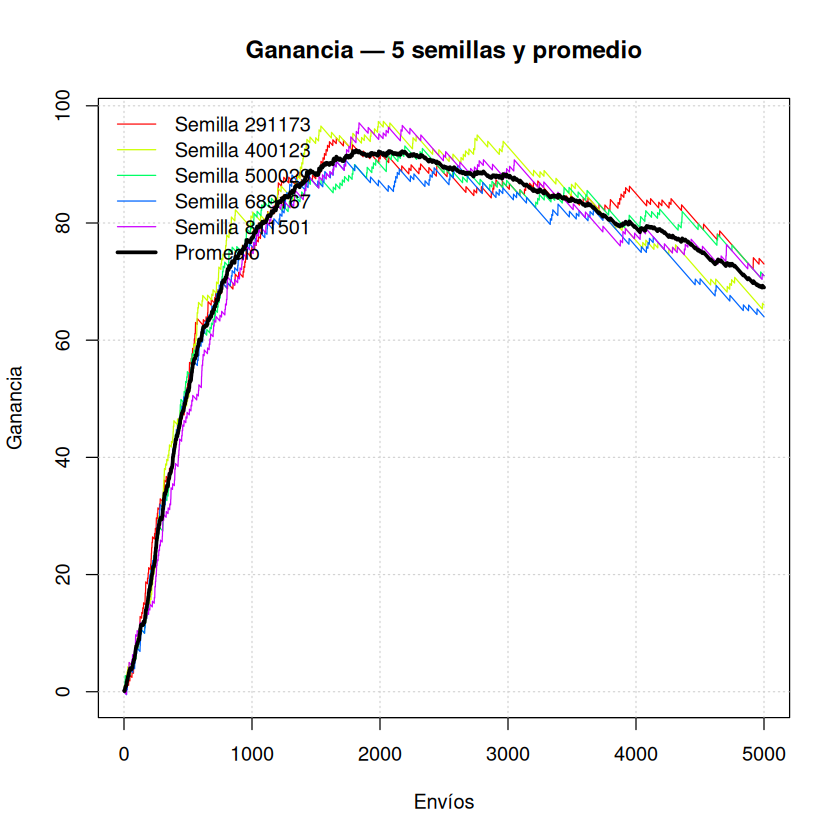

In [13]:
library(data.table)

# ============================================================
# Parámetro configurable
# ============================================================

limite <- 5000


# ============================================================
# Datos
# ============================================================

semillas <- sort(unique(resultados$semilla))

resultados <- fread(
    paste0("curvas_", length(semillas), "_semillas.txt"),
    sep = "\t"
)


# ============================================================
# Curva promedio
# ============================================================

promedio <- resultados[
    ,
    .(
        ganancia_media = mean(ganancia)
    ),
    by = envios
]


# ============================================================
# Función para dibujar el gráfico
# ============================================================

dibujar_grafico <- function() {

    rango <- resultados[
        envios <= limite,
        ganancia
    ]

    plot(
        NA,
        xlim = c(0, limite),
        ylim = range(rango),
        xlab = "Envíos",
        ylab = "Ganancia",
        main = paste0(
            "Ganancia — ",
            length(semillas),
            " semillas y promedio"
        )
    )

    grid()

    # --------------------------------------------------------
    # Curvas individuales
    # --------------------------------------------------------

    for (i in seq_along(semillas)) {

        curva <- resultados[
            semilla == semillas[i] &
            envios <= limite
        ]

        lines(
            curva$envios,
            curva$ganancia,
            col = rainbow(length(semillas))[i]
        )
    }

    # --------------------------------------------------------
    # Curva promedio
    # --------------------------------------------------------

    curva_prom <- promedio[
        envios <= limite
    ]

    lines(
        curva_prom$envios,
        curva_prom$ganancia_media,
        lwd = 3
    )

    # --------------------------------------------------------
    # Leyenda
    # --------------------------------------------------------

    legend(
        "topleft",
        legend = c(
            paste("Semilla", semillas),
            "Promedio"
        ),
        col = c(
            rainbow(length(semillas)),
            "black"
        ),
        lty = 1,
        lwd = c(
            rep(1, length(semillas)),
            3
        ),
        bty = "n"
    )
}


# ============================================================
# 1. Imprimir en JupyterLab
# ============================================================

dibujar_grafico()


# ============================================================
# 2. Guardar como PNG
# ============================================================

png(
    "baseline_5_semillas.png",
    width = 1200,
    height = 800,
    res = 120
)

dibujar_grafico()

dev.off()


# ============================================================
# 3. Guardar como SVG
# ============================================================

svg(
    "baseline_5_semillas.svg",
    width = 10,
    height = 7
)

dibujar_grafico()

dev.off()


# ============================================================
# Verificación
# ============================================================

cat("\nArchivos guardados:\n")
cat("  - baseline_5_semillas.png\n")
cat("  - baseline_5_semillas.svg\n")
cat("\nDirectorio actual:\n")
cat(getwd(), "\n")

agg_record_e0eed655a9 
                    2

agg_record_e0eed655a9 
                    2

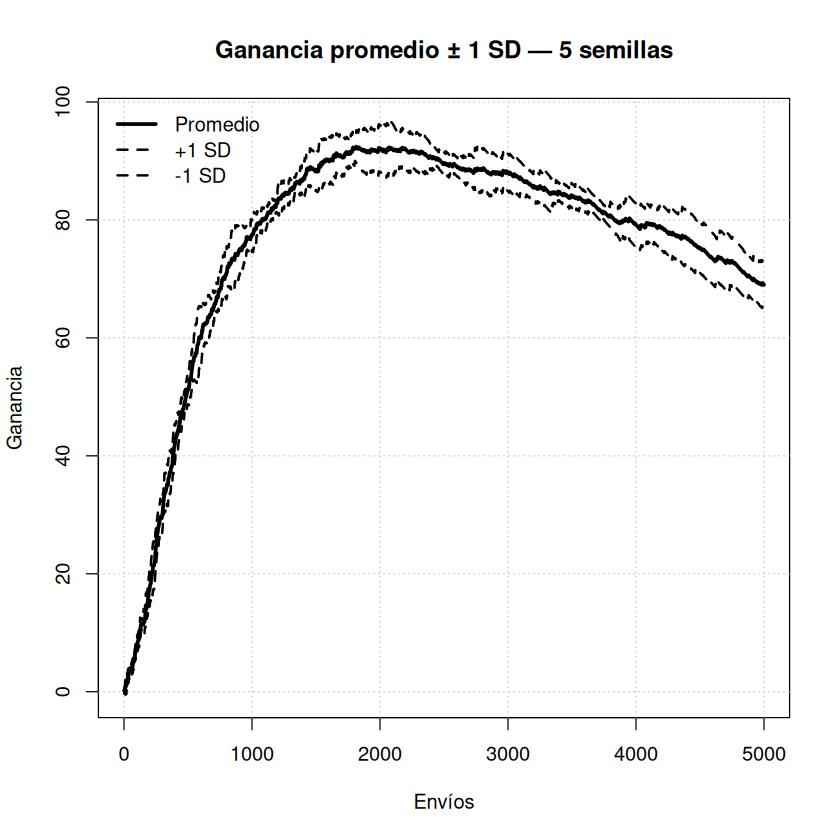

In [14]:
# ============================================================
# Curva promedio ± 1 desvío estándar
# ============================================================

promedio_sd <- resultados[
    ,
    .(
        ganancia_media = mean(ganancia),
        desvio = sd(ganancia)
    ),
    by = envios
]

promedio_sd[
    ,
    ganancia_sup := ganancia_media + desvio
]

promedio_sd[
    ,
    ganancia_inf := ganancia_media - desvio
]


# ============================================================
# Función para dibujar promedio ± SD
# ============================================================

dibujar_grafico_promedio_sd <- function() {

    curva <- promedio_sd[
        envios <= limite
    ]

    rango <- c(
        curva$ganancia_inf,
        curva$ganancia_sup
    )

    plot(
        NA,
        xlim = c(0, limite),
        ylim = range(rango),
        xlab = "Envíos",
        ylab = "Ganancia",
        main = paste0(
            "Ganancia promedio ± 1 SD — ",
            length(semillas),
            " semillas"
        )
    )

    grid()

    # --------------------------------------------------------
    # Media
    # --------------------------------------------------------

    lines(
        curva$envios,
        curva$ganancia_media,
        lwd = 3
    )

    # --------------------------------------------------------
    # +1 SD
    # --------------------------------------------------------

    lines(
        curva$envios,
        curva$ganancia_sup,
        lty = 2,
        lwd = 2
    )

    # --------------------------------------------------------
    # -1 SD
    # --------------------------------------------------------

    lines(
        curva$envios,
        curva$ganancia_inf,
        lty = 2,
        lwd = 2
    )

    # --------------------------------------------------------
    # Leyenda
    # --------------------------------------------------------

    legend(
        "topleft",
        legend = c(
            "Promedio",
            "+1 SD",
            "-1 SD"
        ),
        lty = c(1, 2, 2),
        lwd = c(3, 2, 2),
        bty = "n"
    )
}


# ============================================================
# Imprimir en JupyterLab
# ============================================================

dibujar_grafico_promedio_sd()


# ============================================================
# Guardar PNG
# ============================================================

png(
    "baseline_promedio_mas_menos_sd.png",
    width = 1200,
    height = 800,
    res = 120
)

dibujar_grafico_promedio_sd()

dev.off()


# ============================================================
# Guardar SVG
# ============================================================

svg(
    "baseline_promedio_mas_menos_sd.svg",
    width = 10,
    height = 7
)

dibujar_grafico_promedio_sd()

dev.off()

In [15]:
mejor <- promedio[
    which.max(ganancia_media)
]

mejor

envios,ganancia_media
<int>,<dbl>
1815,92.425


In [16]:
resultados[
    ,
    .(
        ganancia_maxima = max(ganancia),
        envios_maximo = envios[which.max(ganancia)]
    ),
    by = semilla
][order(ganancia_maxima)]

semilla,ganancia_maxima,envios_maximo
<int>,<dbl>,<int>
689167,90.800,1728
500029,93.150,2194
291173,94.525,1659
811501,97.100,1836
400123,97.350,2026
